In [ ]:
# --- INSTALASI ---
!pip install pandas numpy matplotlib tensorflow scikit-learn openpyxl

# --- BAGIAN 1: IMPORT ---=
import pandas as pd             # Alat untuk baca tabel data (Excel/CSV)
import numpy as np              # Alat untuk hitungan matematika
import matplotlib.pyplot as plt # Alat untuk menggambar grafik
import math
import sklearn.metrics as metrics
from sklearn.metrics import mean_squared_error, mean_absolute_error


# alat untuk AI
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, LSTM, Dense, Flatten, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# alat untuk mengubah angka besar (misal: Rp 1 Juta) jadi angka kecil (0-1)
# Biar komputernya tidak pusing hitung angka nol yang kebanyakan.
from sklearn.preprocessing import MinMaxScaler

In [ ]:
#show data
path = "/content/sample_data/dataaa.xlsx"

df = pd.read_excel(path)

df.info()
df

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1853 entries, 0 to 1852
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   Nomor        1853 non-null   object        
 1   Tanggal      1853 non-null   datetime64[ns]
 2   Pelanggan    1853 non-null   object        
 3   Tipe Barang  1853 non-null   object        
 4   Qty          1853 non-null   int64         
 5   Total        1853 non-null   float64       
 6   Sumber       1853 non-null   object        
 7   Notes        1853 non-null   object        
 8   Keterangan   1853 non-null   object        
dtypes: datetime64[ns](1), float64(1), int64(1), object(6)
memory usage: 130.4+ KB


,Nomor,Tanggal,Pelanggan,Tipe Barang,Qty,Total,Sumber,Notes,Keterangan
0,SL/DKS/2024-0458,2024-03-01,"MARYANTI, IBU",CONWOOD,2,1609200.0,Intheria,REPEAT ORDER,End User
1,SL/DKS/2024-0462,2024-03-01,DGA INTERIOR,BALIAN WALL STORAGE,3,976800.0,Intheria,CS - WEBSITE,Konsultan
2,SL/DKS/2024-0460,2024-03-01,"ROBIN, BPK",BALIAN NAIL FREE,37,8330000.0,Intheria,WALK IN,End User
3,SL/DKS/2024-0527,2024-03-01,ILHAM APLIKATOR,BALIAN WALL STORAGE,3,840000.0,Intheria,REPEAT ORDER,Internal
4,SL/DKS/2024-0461,2024-03-02,"ROBIN, BPK",BALIAN WALL PANEL,45,10083200.0,Intheria,WALK IN,End User
...,...,...,...,...,...,...,...,...,...
1848,SI/MKDG/2025-02707,2025-09-09,"NANA, IBU",BALIAN WALL STORAGE,8,1948200.0,Sales,INTHERIA BANDUNG,End User
1849,SI/MKD/2025-3916,2025-09-10,"JADE LIVING INDONESIA, CV",BALIAN WALL STORAGE,30,6158240.0,Sales,REPEAT ORDER,Konsultan
1850,SL/DKS/2025-0073,2025-09-11,"SANDRA, IBU",Conwood,6,2484312.0,Intheria Bdg,WALK IN,End User
1851,SI/MKD/2025-3960,2025-09-12,"NICHO KONTRAKTOR, BPK",BALIAN WALL STORAGE,8,976500.0,Sales,REPEAT ORDER,Konsultan


In [ ]:
#CLEANING DATA
print(df.columns.tolist())

df.columns = df.columns.str.strip().str.lower().str.replace(' ','_')

print("FIX APPLIED")
print(df.columns.tolist())

#date parsing
df['tanggal'] = pd.to_datetime(df['tanggal'])
print(df['tanggal'].dtype)

['Nomor', 'Tanggal', 'Pelanggan', 'Tipe Barang', 'Qty', 'Total', 'Sumber', 'Notes', 'Keterangan']
FIX APPLIED
['nomor', 'tanggal', 'pelanggan', 'tipe_barang', 'qty', 'total', 'sumber', 'notes', 'keterangan']
datetime64[ns]


In [ ]:
df = df.set_index('tanggal')

df['tipe_barang'] = df['tipe_barang'].str.strip().str.lower().str.replace(' ','_')
print(df['tipe_barang'])

#preprocessing data
#encoding
mapping = {
    'conwood': 1,
    'shera': 2,
    'balian_nail_free': 3,
    'balian_wall_panel': 4,
    'balian_wall_storage': 5
}

df['tipe_barang_code'] = df['tipe_barang'].map(mapping)
print(df[['tipe_barang_code','tipe_barang']])

tanggal
2024-03-01                conwood
2024-03-01    balian_wall_storage
2024-03-01       balian_nail_free
2024-03-01    balian_wall_storage
2024-03-02      balian_wall_panel
                     ...         
2025-09-09    balian_wall_storage
2025-09-10    balian_wall_storage
2025-09-11                conwood
2025-09-12    balian_wall_storage
2025-09-12                conwood
Name: tipe_barang, Length: 1853, dtype: object
            tipe_barang_code          tipe_barang
tanggal                                          
2024-03-01                 1              conwood
2024-03-01                 5  balian_wall_storage
2024-03-01                 3     balian_nail_free
2024-03-01                 5  balian_wall_storage
2024-03-02                 4    balian_wall_panel
...                      ...                  ...
2025-09-09                 5  balian_wall_storage
2025-09-10                 5  balian_wall_storage
2025-09-11                 1              conwood
2025-09-12           

In [ ]:
#cek transaksi kosong
transaksi_nol = df[df['total'] == 0]
jumlah_nol_asli = len(transaksi_nol)

print(f"Ada {jumlah_nol_asli} transaksi yang nilainya 0 rupiah di data asli")
if jumlah_nol_asli > 0:
    print("Contoh data 0 di asli:")
    print(transaksi_nol.head())

Ada 0 transaksi yang nilainya 0 rupiah di data asli


In [ ]:
df_models = df[['tipe_barang_code','qty','total']].copy()
print(df_models)

tipe_barang_list = df_models['tipe_barang_code'].unique()
print(tipe_barang_list)

            tipe_barang_code  qty       total
tanggal                                      
2024-03-01                 1    2   1609200.0
2024-03-01                 5    3    976800.0
2024-03-01                 3   37   8330000.0
2024-03-01                 5    3    840000.0
2024-03-02                 4   45  10083200.0
...                      ...  ...         ...
2025-09-09                 5    8   1948200.0
2025-09-10                 5   30   6158240.0
2025-09-11                 1    6   2484312.0
2025-09-12                 5    8    976500.0
2025-09-12                 1    1    760500.0

[1853 rows x 3 columns]
[1 5 3 4 2]


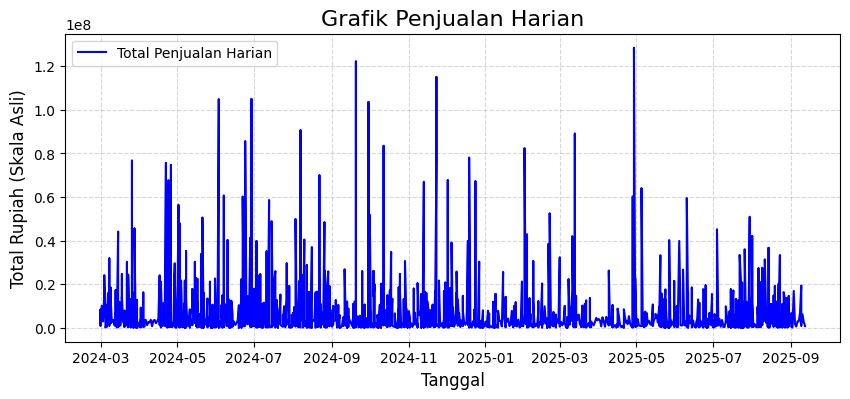

In [ ]:
# Atur ukuran gambar biar lebar dan jelas
plt.figure(figsize=(10, 4))

# Plot data: Sumbu X = Tanggal, Sumbu Y = Total Penjualan
plt.plot(df_models.index, df_models['total'], label='Total Penjualan Harian', color='blue')

# Beri judul dan label
plt.title('Grafik Penjualan Harian', fontsize=16)
plt.xlabel('Tanggal', fontsize=12)
plt.ylabel('Total Rupiah (Skala Asli)', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5) # Tambah garis bantu kotak-kotak

# Tampilkan
plt.show()


In [ ]:
def create_window(data, window_size, target_col_index):

    X, y = [], []

    for i in range(len(data) - window_size):
        X.append(data[i:i+window_size, :])
        y.append(data[i+window_size, target_col_index])

    return np.array(X), np.array(y)

In [ ]:
def build_model(window_size, n_features):

    model = Sequential()

    model.add(Conv1D(filters=64,
                     kernel_size=3,
                     activation='relu',
                     input_shape=(window_size, n_features)))

    model.add(MaxPooling1D(pool_size=2))

    model.add(LSTM(50))

    model.add(Dense(1))

    optimizer = tf.keras.optimizers.RMSprop(learning_rate=0.01)

    model.compile(optimizer=optimizer,
                  loss='mse')

    return model


In [ ]:
window_size = 30
future_days = 30

hasil_prediksi = {}
hasil_evaluasi = {}
hasil_forecast = {}
hasil_aktual = {} # New dictionary to store actual values

# New dictionaries to store X_train, X_test, y_train, y_test for each item type
all_X_train = {}
all_X_test = {}
all_y_train = {}
all_y_test = {}

for nama_tipe, kode_tipe in mapping.items():

    print("===================================")
    print("PROSES TIPE:", nama_tipe)

    # ------------------------
    # FILTER DATA
    # ------------------------

    df_tipe = df[df['tipe_barang_code'] == kode_tipe]

    df_tipe = df_tipe.groupby('tanggal').agg({
        'tipe_barang_code':'first',
        'qty':'sum',
        'total':'sum'
    }).reset_index()

    # ------------------------
    # AMBIL FITUR
    # ------------------------

    features = ['tipe_barang_code','qty','total']
    target_col_index = features.index('total')

    data = df_tipe[features].values

    # ------------------------
    # NORMALISASI
    # ------------------------

    scaler = MinMaxScaler()
    data_scaled = scaler.fit_transform(data)

    # ------------------------
    # WINDOWING
    # ------------------------

    X, y = create_window(
        data_scaled,
        window_size,
        target_col_index
    )

    # ------------------------
    # SPLIT DATA
    # ------------------------

    split = int(0.8 * len(X))

    X_train, X_test = X[:split], X[split:]
    y_train, y_test = y[:split], y[split:]

    # Store for later inspection
    all_X_train[nama_tipe] = X_train
    all_X_test[nama_tipe] = X_test
    all_y_train[nama_tipe] = y_train
    all_y_test[nama_tipe] = y_test

    # ------------------------
    # BUILD MODEL
    # ------------------------

    n_features = X_train.shape[2]

    model = build_model(window_size, n_features)

    model.fit(
        X_train,
        y_train,
        epochs=40,
        batch_size=8,
        validation_split=0.1,
        verbose=0
    )

    # ------------------------
    # PREDIKSI TEST
    # ------------------------

    y_pred_scaled = model.predict(X_test)

    # ============================
    # INVERSE SCALE TOTAL SAJA
    # ============================

    temp_pred = np.zeros((len(y_pred_scaled), 3))
    temp_real = np.zeros((len(y_test), 3))

    temp_pred[:, target_col_index] = y_pred_scaled.flatten()
    temp_real[:, target_col_index] = y_test.flatten()

    y_pred = scaler.inverse_transform(temp_pred)[:, target_col_index]
    y_real = scaler.inverse_transform(temp_real)[:, target_col_index]

    # ------------------------
    # EVALUASI
    # ------------------------

    mae = np.log1p(mean_absolute_error(y_real, y_pred))
    rmse = np.sqrt(mean_squared_error(y_real, y_pred))

    print("MAE :", mae)
    print("RMSE:", np.log1p(rmse))

    hasil_prediksi[nama_tipe] = y_pred
    hasil_aktual[nama_tipe] = y_real # Store actual values
    hasil_evaluasi[nama_tipe] = [mae, rmse]

    # ============================
    # FORECAST MULTIVARIATE
    # ============================

    last_window = data_scaled[-window_size:]

    future_list = []

    for i in range(future_days):

        input_data = last_window.reshape(1, window_size, n_features)

        next_pred = model.predict(input_data)

        new_row = last_window[-1].copy()
        new_row[target_col_index] = next_pred[0][0]

        future_list.append(new_row)

        last_window = np.vstack((last_window[1:], new_row))

    future_array = np.array(future_list)

    future_inverse = scaler.inverse_transform(future_array)

    hasil_forecast[nama_tipe] = future_inverse[:, target_col_index]

PROSES TIPE: conwood


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 191ms/step
MAE : 15.893350861630209
RMSE: 16.236753933871245
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 213ms/step
MAE : 16.111167993506147
RMSE: 16.31756566592875
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step


...

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 187ms/step
MAE : 15.640941815506395
RMSE: 16.107488494104928
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 189ms/step
MAE : 15.974180901442915
RMSE: 16.26857667636773
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 196ms/step
MAE : 16.654909918107037
RMSE: 16.691242023611807
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step

In [ ]:
print("\nX_train untuk setiap tipe barang:")
for nama_tipe, x_train_data in all_X_train.items():
    print(f"\n--- Tipe Barang: {nama_tipe} ---")
    print(f"Bentuk X_train: {x_train_data.shape}")
    print(x_train_data)


X_train untuk setiap tipe barang:

--- Tipe Barang: conwood ---
Bentuk X_train: (178, 30, 3)
[[[0.         0.00288184 0.01332776]
  [0.         0.         0.00221076]
  [0.         0.02305476 0.04109721]
  ...
  [0.         0.04610951 0.09042924]
  [0.         0.00864553 0.01682315]
  [0.         0.06628242 0.07662106]]

 [[0.         0.         0.00221076]
  [0.         0.02305476 0.04109721]
  [0.         0.12680115 0.12989487]
  ...
  [0.         0.00864553 0.01682315]
  [0.         0.06628242 0.07662106]
  [0.         0.08069164 0.06809102]]

 [[0.         0.02305476 0.04109721]
  [0.         0.12680115 0.12989487]
  [0.         0.05763689 0.12214026]
  ...
  [0.         0.06628242 0.07662106]
  [0.         0.08069164 0.06809102]
  [0.         0.02881844 0.0267007 ]]

 ...

 [[0.         0.01440922 0.01892556]
  [0.         0.01729107 0.01835579]
  [0.         0.         0.00050092]
  ...
  [0.         0.03746398 0.04485311]
  [0.         0.00288184 0.00257125]
  [0.         0.046


Visualisasi untuk Tipe Barang: conwood


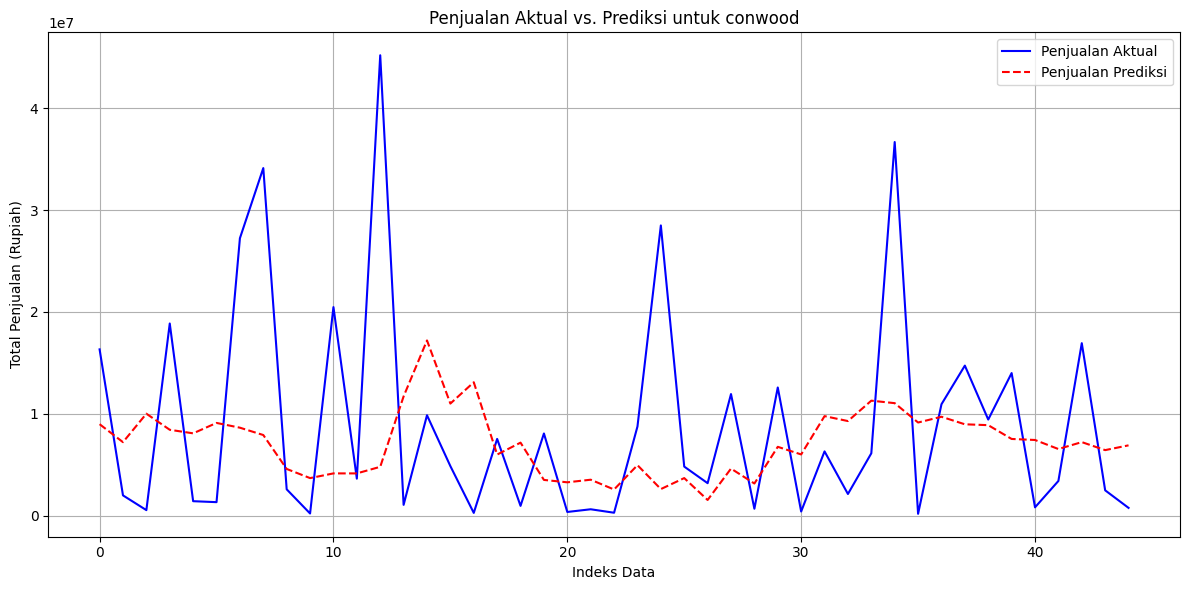


Visualisasi untuk Tipe Barang: shera


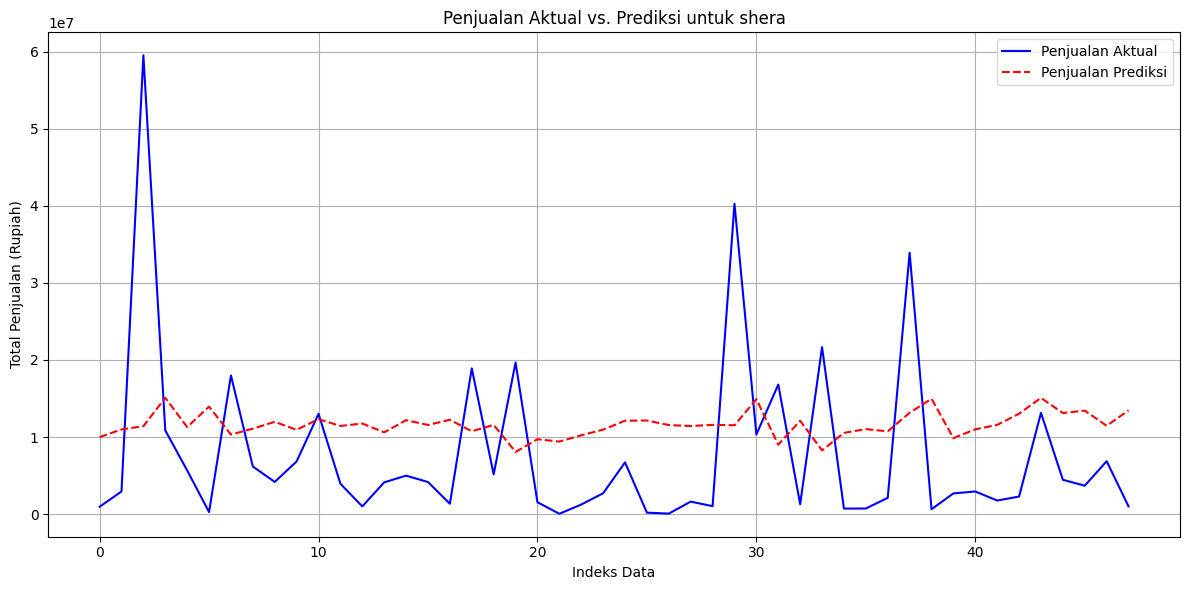


Visualisasi untuk Tipe Barang: balian_nail_free


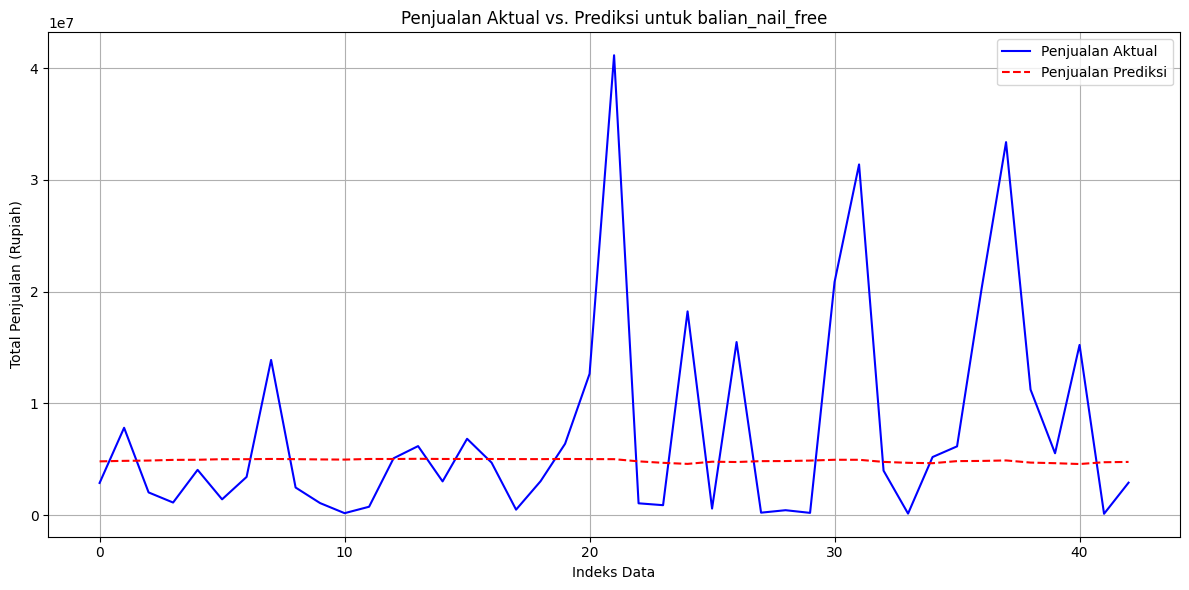


Visualisasi untuk Tipe Barang: balian_wall_panel


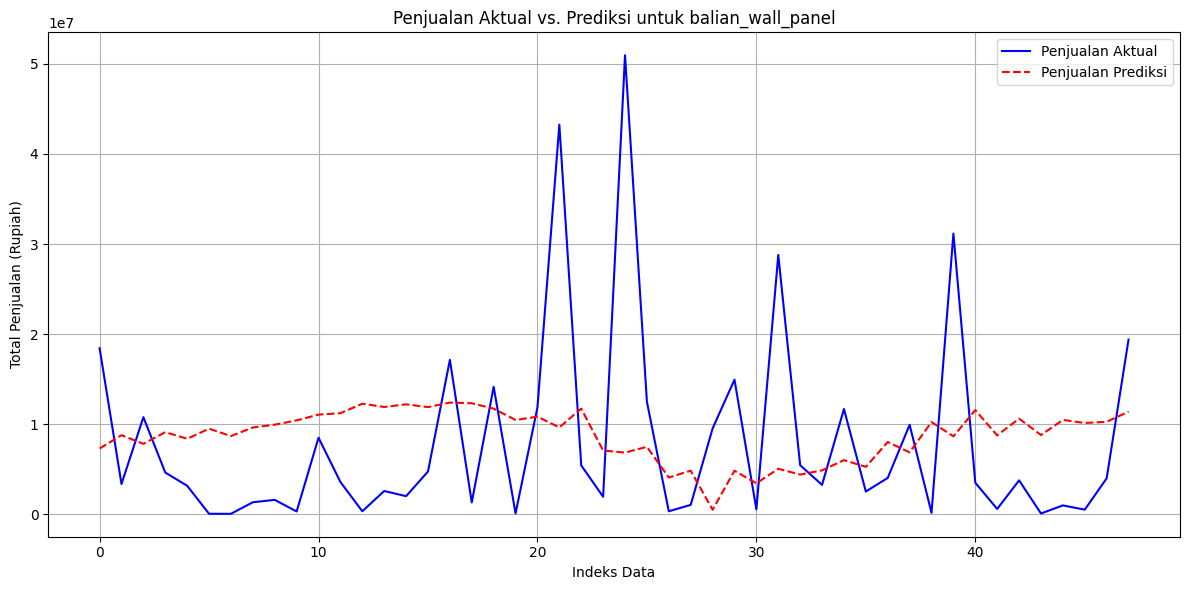


Visualisasi untuk Tipe Barang: balian_wall_storage


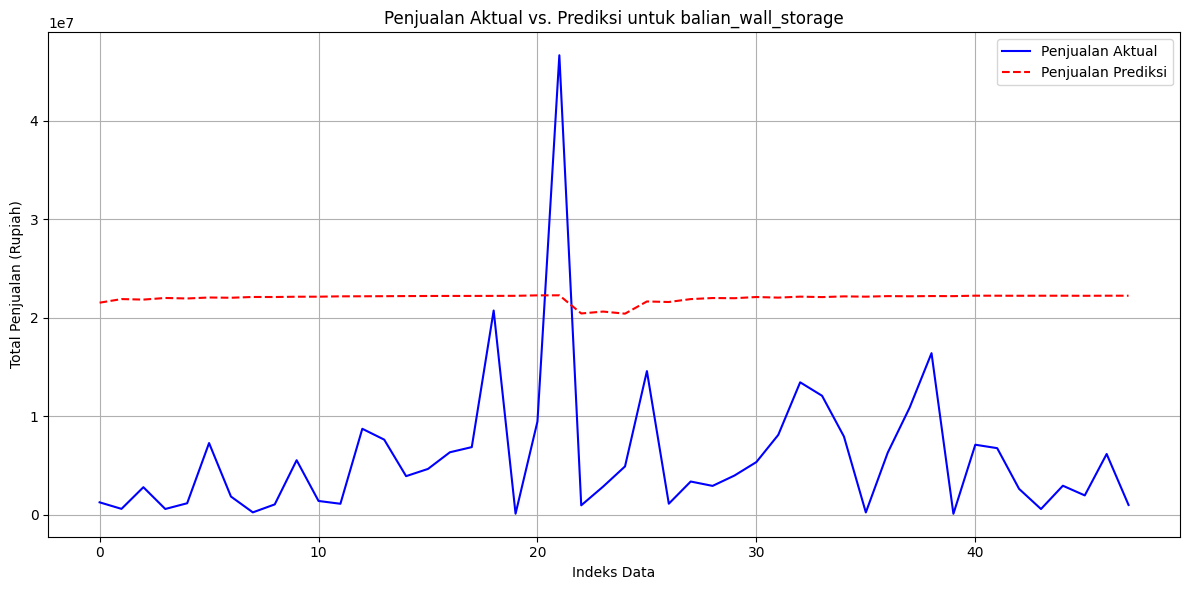

In [ ]:
for nama_tipe in mapping.keys():
    print(f"\nVisualisasi untuk Tipe Barang: {nama_tipe}")

    # Dapatkan data aktual dan prediksi untuk tipe saat ini
    actual_values = hasil_aktual[nama_tipe]
    predicted_values = hasil_prediksi[nama_tipe]

    # Rekonstruksi tanggal untuk set pengujian
    df_tipe = df[df['tipe_barang_code'] == mapping[nama_tipe]].copy()
    df_tipe = df_tipe.groupby('tanggal')['total'].sum().reset_index()

    # Untuk mendapatkan tanggal yang sesuai dengan y_test_inv dan y_pred_inv,
    # kita perlu menggunakan logika windowing dan splitting yang sama.
    # 'data' di sini adalah data asli yang sudah di-log1p dan siap untuk scaling,
    # sebelum di-windowing.
    temp_data = np.log1p(df_tipe[['total']]).values

    # Buat X dan y seperti di proses pelatihan untuk mendapatkan panjang yang benar
    temp_X, temp_y = create_window(temp_data, window_size, 0) # The target_col_index is 0 because temp_data only has one column now

    # Tentukan split point yang sama
    split = int(0.8 * len(temp_X))

    # Tanggal yang sesuai dengan y_test_inv (data asli setelah windowing dan split)
    test_dates = df_tipe['tanggal'].iloc[window_size + split:]

    plt.figure(figsize=(12, 6))
    # Plot terhadap indeks numerik daripada tanggal
    plt.plot(np.arange(len(actual_values)), actual_values, label='Penjualan Aktual', color='blue')
    plt.plot(np.arange(len(predicted_values)), predicted_values, label='Penjualan Prediksi', color='red', linestyle='--')
    plt.title(f'Penjualan Aktual vs. Prediksi untuk {nama_tipe}')
    # Mengganti label sumbu X menjadi 'Indeks Data'
    plt.xlabel('Indeks Data')
    plt.ylabel('Total Penjualan (Rupiah)')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


--- Visualisasi Prediksi dan Forecast untuk Tipe Barang: conwood ---


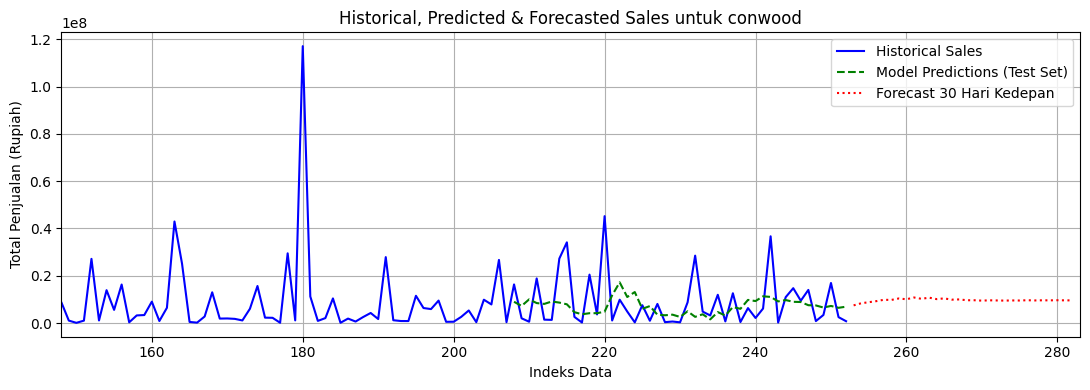


--- Nilai Forecast (30 hari) untuk conwood: ---
   Tanggal  Total Penjualan Forecast
2025-09-13              7.460211e+06
2025-09-14              8.345941e+06
2025-09-15              8.795317e+06
2025-09-16              9.244801e+06
2025-09-17              9.819108e+06
2025-09-18              9.762267e+06
2025-09-19              1.038068e+07
2025-09-20              1.003964e+07
2025-09-21              1.079002e+07
2025-09-22              1.022928e+07
2025-09-23              1.072226e+07
2025-09-24              1.010825e+07
2025-09-25              1.040664e+07
2025-09-26              9.877227e+06
2025-09-27              9.975608e+06
2025-09-28              9.626538e+06
2025-09-29              9.625934e+06
2025-09-30              9.461420e+06
2025-10-01              9.600191e+06
2025-10-02              9.537159e+06
2025-10-03              9.472127e+06
2025-10-04              9.544649e+06
2025-10-05              9.511130e+06
2025-10-06              9.638832e+06
2025-10-07              9.

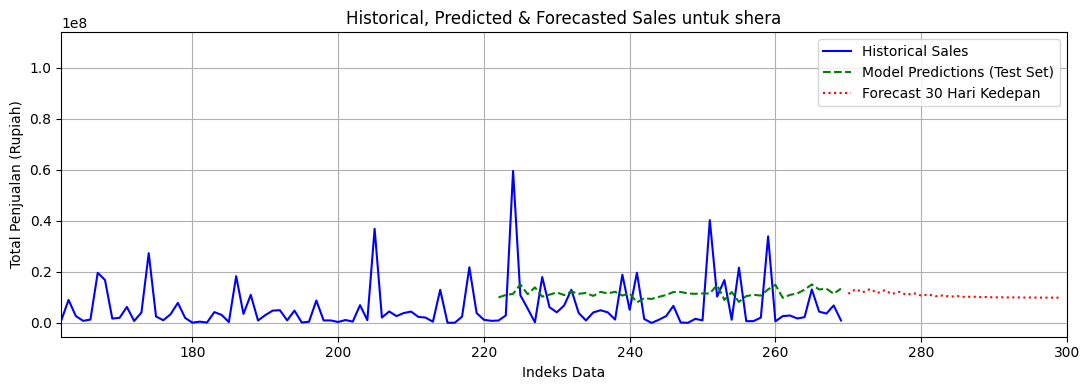


--- Nilai Forecast (30 hari) untuk shera: ---
   Tanggal  Total Penjualan Forecast
2025-09-10              1.143621e+07
2025-09-11              1.323815e+07
2025-09-12              1.203822e+07
2025-09-13              1.330594e+07
2025-09-14              1.175104e+07
2025-09-15              1.280990e+07
2025-09-16              1.135208e+07
2025-09-17              1.221717e+07
2025-09-18              1.100683e+07
2025-09-19              1.167155e+07
2025-09-20              1.073922e+07
2025-09-21              1.118444e+07
2025-09-22              1.048189e+07
2025-09-23              1.079693e+07
2025-09-24              1.031475e+07
2025-09-25              1.053174e+07
2025-09-26              1.019243e+07
2025-09-27              1.033569e+07
2025-09-28              1.012433e+07
2025-09-29              1.017111e+07
2025-09-30              1.002883e+07
2025-10-01              1.006267e+07
2025-10-02              9.998146e+06
2025-10-03              1.001610e+07
2025-10-04              9.97

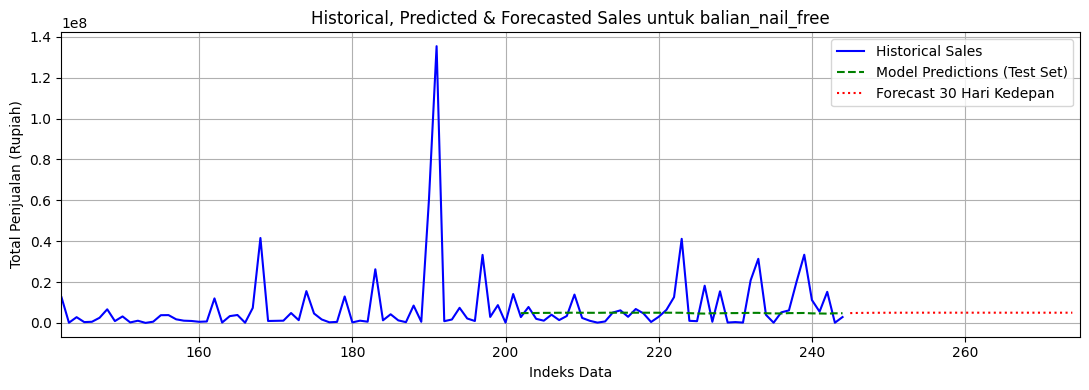


--- Nilai Forecast (30 hari) untuk balian_nail_free: ---
   Tanggal  Total Penjualan Forecast
2025-09-07              4.836881e+06
2025-09-08              4.915863e+06
2025-09-09              4.950942e+06
2025-09-10              4.983999e+06
2025-09-11              4.999173e+06
2025-09-12              5.014158e+06
2025-09-13              5.020628e+06
2025-09-14              5.027683e+06
2025-09-15              5.029612e+06
2025-09-16              5.033604e+06
2025-09-17              5.034136e+06
2025-09-18              5.036297e+06
2025-09-19              5.035815e+06
2025-09-20              5.037258e+06
2025-09-21              5.036309e+06
2025-09-22              5.037507e+06
2025-09-23              5.036272e+06
2025-09-24              5.036530e+06
2025-09-25              5.035239e+06
2025-09-26              5.035812e+06
2025-09-27              5.035125e+06
2025-09-28              5.035403e+06
2025-09-29              5.034720e+06
2025-09-30              5.034445e+06
2025-10-01       

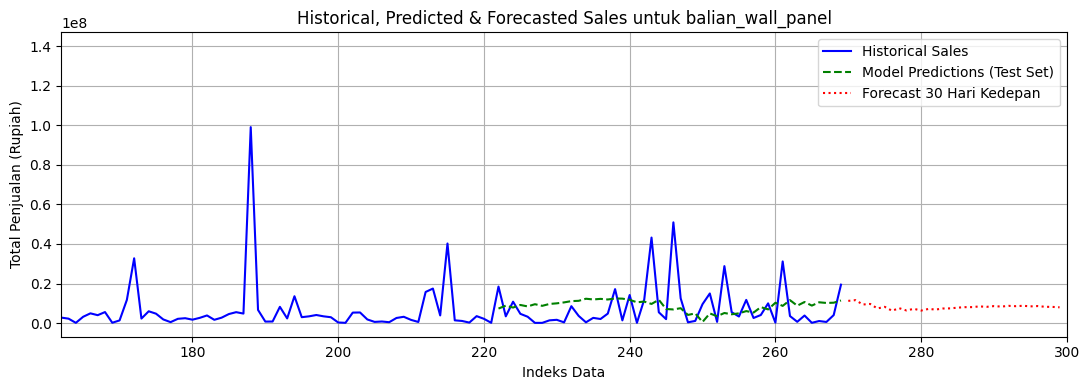


--- Nilai Forecast (30 hari) untuk balian_wall_panel: ---
   Tanggal  Total Penjualan Forecast
2025-09-10              1.120498e+07
2025-09-11              1.156953e+07
2025-09-12              9.361463e+06
2025-09-13              9.653939e+06
2025-09-14              7.359800e+06
2025-09-15              8.188049e+06
2025-09-16              6.215984e+06
2025-09-17              7.485289e+06
2025-09-18              6.335709e+06
2025-09-19              7.190339e+06
2025-09-20              6.297164e+06
2025-09-21              7.122698e+06
2025-09-22              6.809255e+06
2025-09-23              7.341750e+06
2025-09-24              7.404142e+06
2025-09-25              7.774336e+06
2025-09-26              8.016386e+06
2025-09-27              8.041599e+06
2025-09-28              8.400380e+06
2025-09-29              8.191643e+06
2025-09-30              8.556454e+06
2025-10-01              8.304026e+06
2025-10-02              8.688258e+06
2025-10-03              8.512918e+06
2025-10-04      

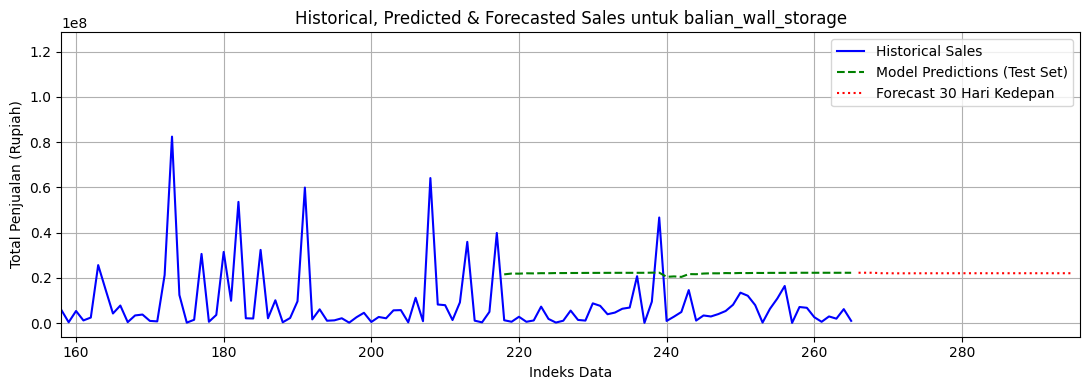


--- Nilai Forecast (30 hari) untuk balian_wall_storage: ---
   Tanggal  Total Penjualan Forecast
2025-09-13              2.225282e+07
2025-09-14              2.225352e+07
2025-09-15              2.225767e+07
2025-09-16              2.205587e+07
2025-09-17              2.203339e+07
2025-09-18              2.199752e+07
2025-09-19              2.200133e+07
2025-09-20              2.200860e+07
2025-09-21              2.201255e+07
2025-09-22              2.202021e+07
2025-09-23              2.202162e+07
2025-09-24              2.202685e+07
2025-09-25              2.202782e+07
2025-09-26              2.203112e+07
2025-09-27              2.203206e+07
2025-09-28              2.203398e+07
2025-09-29              2.203490e+07
2025-09-30              2.203592e+07
2025-10-01              2.203667e+07
2025-10-02              2.203715e+07
2025-10-03              2.203790e+07
2025-10-04              2.203807e+07
2025-10-05              2.203853e+07
2025-10-06              2.203857e+07
2025-10-07    

In [ ]:
from datetime import timedelta

for nama_tipe in mapping.keys():
    print(f"\n--- Visualisasi Prediksi dan Forecast untuk Tipe Barang: {nama_tipe} ---")

    # Dapatkan data aktual dan prediksi untuk tipe saat ini
    actual_values = hasil_aktual[nama_tipe]
    predicted_values = hasil_prediksi[nama_tipe]
    forecast_values = hasil_forecast[nama_tipe]

    # Rekonstruksi tanggal untuk set pengujian
    df_tipe = df[df['tipe_barang_code'] == mapping[nama_tipe]].copy()
    df_tipe = df_tipe.groupby('tanggal')['total'].sum().reset_index()

    # Buat X dan y seperti di proses pelatihan untuk mendapatkan panjang yang benar
    temp_data = np.log1p(df_tipe[['total']]).values # Re-create temp_data using log1p
    temp_X, temp_y = create_window(temp_data, window_size, 0)

    # Tentukan split point yang sama
    split = int(0.8 * len(temp_X))

    # Tanggal yang sesuai dengan y_test_inv (data asli setelah windowing dan split)
    test_dates = df_tipe['tanggal'].iloc[window_size + split:]

    # Ambil tanggal terakhir dari data aktual/test untuk memulai forecast
    last_actual_date = test_dates.iloc[-1] if not test_dates.empty else df_tipe['tanggal'].max()

    # Buat tanggal untuk periode forecast
    forecast_dates = pd.date_range(start=last_actual_date + timedelta(days=1), periods=future_days)

    plt.figure(figsize=(11, 4))
    # Plot seluruh data historis terhadap indeks numerik
    plt.plot(np.arange(len(df_tipe)), df_tipe['total'], label='Historical Sales', color='blue')
    # Overlay prediksi model pada set pengujian terhadap indeks numerik yang sesuai
    plt.plot(np.arange(len(df_tipe) - len(test_dates), len(df_tipe)), predicted_values, label='Model Predictions (Test Set)', color='green', linestyle='--')
    # Overlay perkiraan untuk masa depan terhadap indeks numerik yang melanjutkan data historis
    plt.plot(np.arange(len(df_tipe), len(df_tipe) + len(forecast_values)), forecast_values, label=f'Forecast {future_days} Hari Kedepan', color='red', linestyle=':')

    # Atur batas sumbu X agar time frame terlihat lebih besar dan fokus pada bagian akhir
    start_index_for_xlim = max(0, len(df_tipe) - (len(test_dates) + (2 * window_size))) # Mulai dari 2 * window_size sebelum test set
    end_index_for_xlim = len(df_tipe) + len(forecast_values)
    plt.xlim(start_index_for_xlim, end_index_for_xlim)

    plt.title(f'Historical, Predicted & Forecasted Sales untuk {nama_tipe}')
    plt.xlabel('Indeks Data') # Mengganti label sumbu X menjadi 'Indeks Data'
    plt.ylabel('Total Penjualan (Rupiah)')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    print(f"\n--- Nilai Forecast ({future_days} hari) untuk {nama_tipe}: ---")
    forecast_df = pd.DataFrame({'Tanggal': forecast_dates, 'Total Penjualan Forecast': forecast_values})
    print(forecast_df.to_string(index=False))